## 데이터 불러오기

In [ ]:
import os
from google.colab import drive, auth
import zipfile

# Google Drive 마운트 및 API 인증
drive.mount('/content/drive')
auth.authenticate_user() # Google Drive API 사용을 위한 인증

# 저장할 구글 드라이브 폴더 ID (사용자가 제공한 URL에서 추출)
drive_folder_id = '1teiRbwW4ciSrKLd4bvs7kc81Y5q3lkwV'

# 로컬 저장 경로 설정
output_dir = '/content/output_files'
os.makedirs(output_dir, exist_ok=True)

Mounted at /content/drive


In [ ]:
#통합된 데이터 사용

import pandas as pd
df = pd.read_pickle('/content/레몬테라스_에어컨 구매.pickle')
print(df.head())

                                     title  \
0                      전자랜드나 하이마트와 인터넷으로~    
1         (용인) 이사하면서 가전제품 삼성 풀세트로 맞췄어요 ㅎㅎ    
2                         다들 에어컨 청소 하시나요?    
3   (수정) 전 세입자가 협의 없이 설치한 붙박이장 살까요 말까요 ㅎㅎ    
4               쓸만한 에어컨 세탁기 바꿀때 그냥 버리시나요?    

                                             content  \
0  \n에어컨구매시 매장과 인터넷. 설치비 차이가​있나요?​가격은 천차만별인데 인터넷은...   
1  \n가전은 엘지냐 삼성이냐 계속 두고 고민하면서 온라인 쇼핑가격 찾아보고 하다가 삼...   
2  \n할까말까 고민중이었는데, ​동네분들 어디서하나 요기조기 견적도 받아보고​알아보다...   
3  \n앗 댓글들 모두 감사드립니다원복요청해야겠네요. 어찌저찌 놔두고 공사가 가능하려나...   
4  \n에어컨 세탁기 .. 잘돌아가고 문제없고 구매 5년된 건데당근에 내놔도 될까요?우...   

                                             comment         date view  \
0                                                 []  2026.03.10.   18   
1                                                 []  2026.03.09.   42   
2                                               [광고]  2026.03.06.   59   
3                                                 []  2026.03.05.  155   
4  [네 당근으로 하세요~\

## 데이터 전처리

In [ ]:
import re

# 데이터프레임 중복값 제거
initial_rows = len(df)
df.drop_duplicates(inplace=True)
print(f"중복값 제거 후 {initial_rows - len(df)}개의 행이 삭제되었습니다. 남은 행 수: {len(df)}")

# 'content' 컬럼의 NaN 값 제거
initial_rows = len(df)
df.dropna(subset=['content'], inplace=True)
print(f"'content' 컬럼의 NaN 값 제거 후 {initial_rows - len(df)}개의 행이 삭제되었습니다. 남은 행 수: {len(df)}")

def clean_text(text):

    # URL 제거
    text = re.sub(r"http\S+", "", text)

    # HTML 제거
    text = re.sub(r"<.*?>", "", text)

    # 멘션 제거
    text = re.sub(r"@\w+", "", text)

    # ㅋㅋㅋㅋ → ㅋㅋ
    text = re.sub(r"(ㅋ)\\1{2,}", "ㅋㅋ", text)

    # ㅎㅎㅎㅎ → ㅎㅎ
    text = re.sub(r"(ㅎ)\\1{2,}", "ㅎㅎ", text)

    # !!!!! → !
    text = re.sub(r"!{2,}", "!", text)

    # ????? → ?
    text = re.sub(r"\\?{2,}", "?", text)

    # 공백 정리
    text = re.sub(r"\\s+", " ", text)

    return text.strip()

In [ ]:
initial_rows = len(df)
df.drop_duplicates(inplace=True)
print(f"중복값 제거 후 {initial_rows - len(df)}개의 행이 삭제되었습니다. 남은 행 수: {len(df)}")
df['merged_content'] = df['merged_content'].apply(clean_text)

## 모델 불러오기

In [ ]:
import torch
from sentence_transformers import SentenceTransformer

# GPU 사용 가능 여부 확인
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# 모델 로드
model = SentenceTransformer("jhgan/ko-sroberta-multitask",device=device)

# content 컬럼을 리스트로 변환
texts = df['content'].astype(str).tolist()

# 임베딩 생성
embeddings = model.encode(texts, batch_size=32, show_progress_bar=True)

# dataframe에 vector 컬럼 추가
df['vector'] = embeddings.tolist()

# 확인
df.head()

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

,title,content,comment,date,view,url,vector
0,전자랜드나 하이마트와 인터넷으로~,\n에어컨구매시 매장과 인터넷. 설치비 차이가​있나요?​가격은 천차만별인데 인터넷은...,[],2026.03.10.,18,https://cafe.naver.com/f-e/cafes/10298136/arti...,"[-0.1411142647266388, -0.2588972747325897, -0...."
1,(용인) 이사하면서 가전제품 삼성 풀세트로 맞췄어요 ㅎㅎ,\n가전은 엘지냐 삼성이냐 계속 두고 고민하면서 온라인 쇼핑가격 찾아보고 하다가 삼...,[],2026.03.09.,42,https://cafe.naver.com/f-e/cafes/10298136/arti...,"[0.028771519660949707, 0.09602583944797516, 0...."
2,다들 에어컨 청소 하시나요?,"\n할까말까 고민중이었는데, ​동네분들 어디서하나 요기조기 견적도 받아보고​알아보다...",[광고],2026.03.06.,59,https://cafe.naver.com/f-e/cafes/10298136/arti...,"[-0.4350138306617737, -0.26647478342056274, -0..."
3,(수정) 전 세입자가 협의 없이 설치한 붙박이장 살까요 말까요 ㅎㅎ,\n앗 댓글들 모두 감사드립니다원복요청해야겠네요. 어찌저찌 놔두고 공사가 가능하려나...,[],2026.03.05.,155,https://cafe.naver.com/f-e/cafes/10298136/arti...,"[-0.6261348128318787, -0.23831601440906525, -0..."
4,쓸만한 에어컨 세탁기 바꿀때 그냥 버리시나요?,\n에어컨 세탁기 .. 잘돌아가고 문제없고 구매 5년된 건데당근에 내놔도 될까요?우...,[네 당근으로 하세요~\n싸게 내놓으면 바로 팔려요.\n혹시 새로 가전바꿀때 밑으로...,2026.03.05.,71,https://cafe.naver.com/f-e/cafes/10298136/arti...,"[-0.5623260736465454, -0.15700693428516388, 0...."


In [ ]:
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload
import os

# DataFrame 저장 (CSV)
df_filename = os.path.join(output_dir, 'kure_embedding_data.csv')
df.to_csv(df_filename, index=False)
print(f"DataFrame saved to {df_filename}")

# Google Drive API를 사용하여 CSV 파일 업로드
drive_service = build('drive', 'v3')

if os.path.exists(df_filename):
    file_metadata = {
        'name': os.path.basename(df_filename),
        'parents': [drive_folder_id]
    }
    media = MediaFileUpload(df_filename, resumable=True)
    uploaded_file = drive_service.files().create(
        body=file_metadata,
        media_body=media,
        fields='id'
    ).execute()
    print(f"Uploaded '{os.path.basename(df_filename)}' to Google Drive folder ID: {drive_folder_id}. File ID: {uploaded_file.get('id')}")
else:
    print(f"Warning: CSV file not found for upload - {df_filename}")

print("CSV file has been processed and uploaded to Google Drive.")

## 클러스터링 시각화 해서 확인하기

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib import pyplot as plt

## 덴드로그램

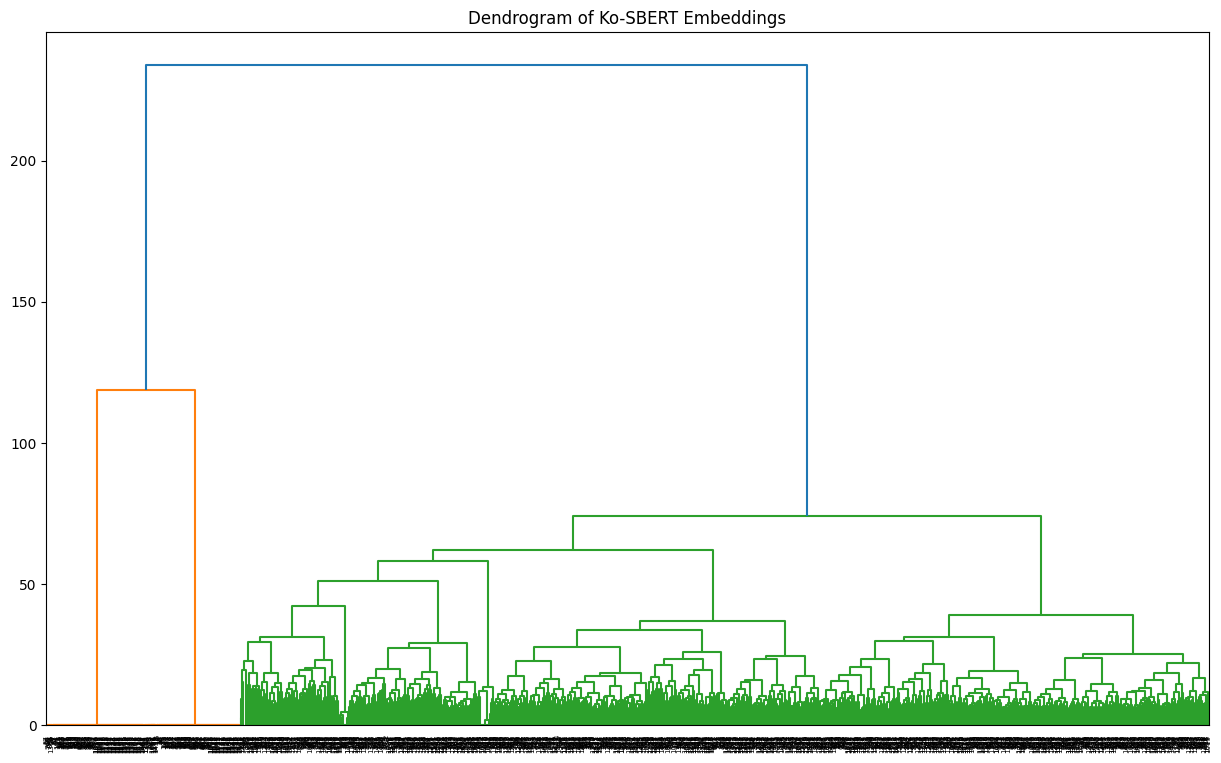

Dendrogram saved to /content/output_files/dendrogram.png


In [ ]:
import os

link_model = linkage(list(df['vector']), 'ward') #ward 병합 기준으로

plt.figure(figsize=(15,9))
dendrogram(link_model,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False)
plt.title('Dendrogram of Ko-SBERT Embeddings')

output_dir = '/content/output_files'
os.makedirs(output_dir, exist_ok=True)
dendrogram_filename = os.path.join(output_dir, 'dendrogram.png')
plt.savefig(dendrogram_filename)
plt.show()
print(f"Dendrogram saved to {dendrogram_filename}")
plt.close() # Close the plot to free memory

## UMAP

In [ ]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


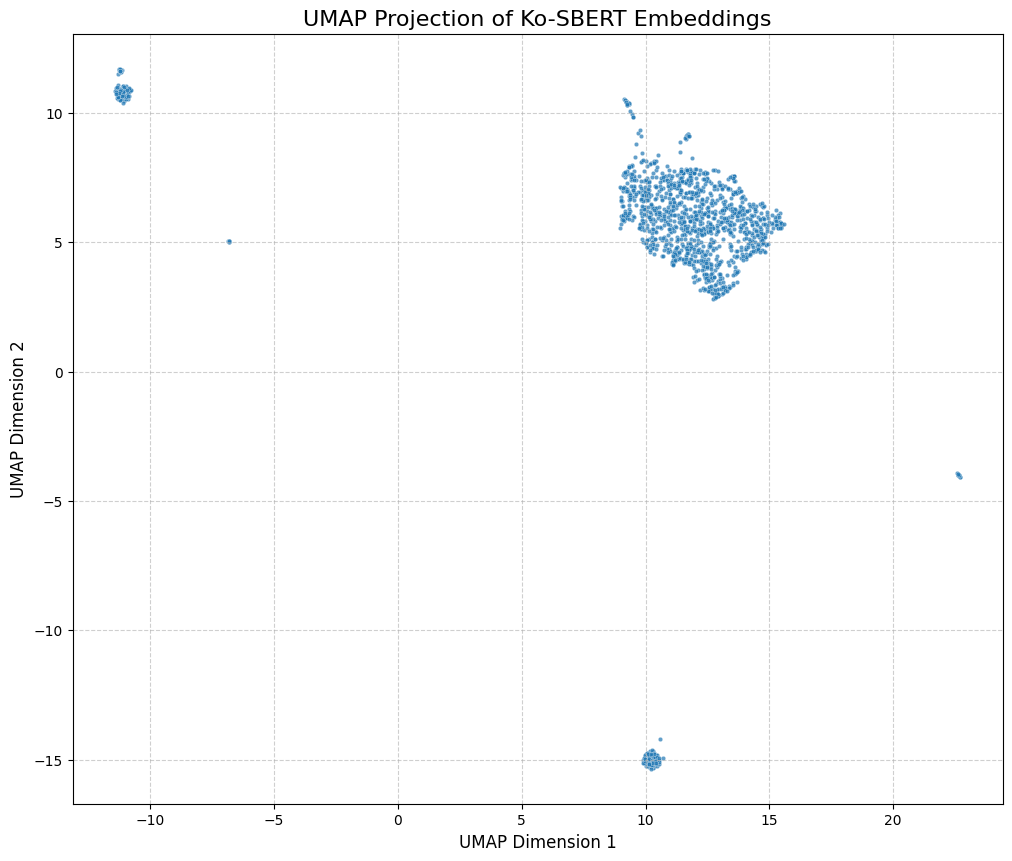

UMAP plot saved to /content/output_files/umap_projection.png


In [ ]:
import umap
import seaborn as sns
import os

umap_reducer = umap.UMAP(n_components=2, random_state=42)

embedding = umap_reducer.fit_transform(list(df['vector']))

df['umap_x'] = embedding[:, 0]
df['umap_y'] = embedding[:, 1]

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='umap_x',
    y='umap_y',
    data=df,
    s=10, # 점 크기
    alpha=0.7 # 투명도
)
plt.title('UMAP Projection of Ko-SBERT Embeddings', fontsize=16)
plt.xlabel('UMAP Dimension 1', fontsize=12)
plt.ylabel('UMAP Dimension 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

output_dir = '/content/output_files'
os.makedirs(output_dir, exist_ok=True)
umap_filename = os.path.join(output_dir, 'umap_projection.png')
plt.savefig(umap_filename)
plt.show()
print(f"UMAP plot saved to {umap_filename}")
plt.close() # Close the plot to free memory

## PCA

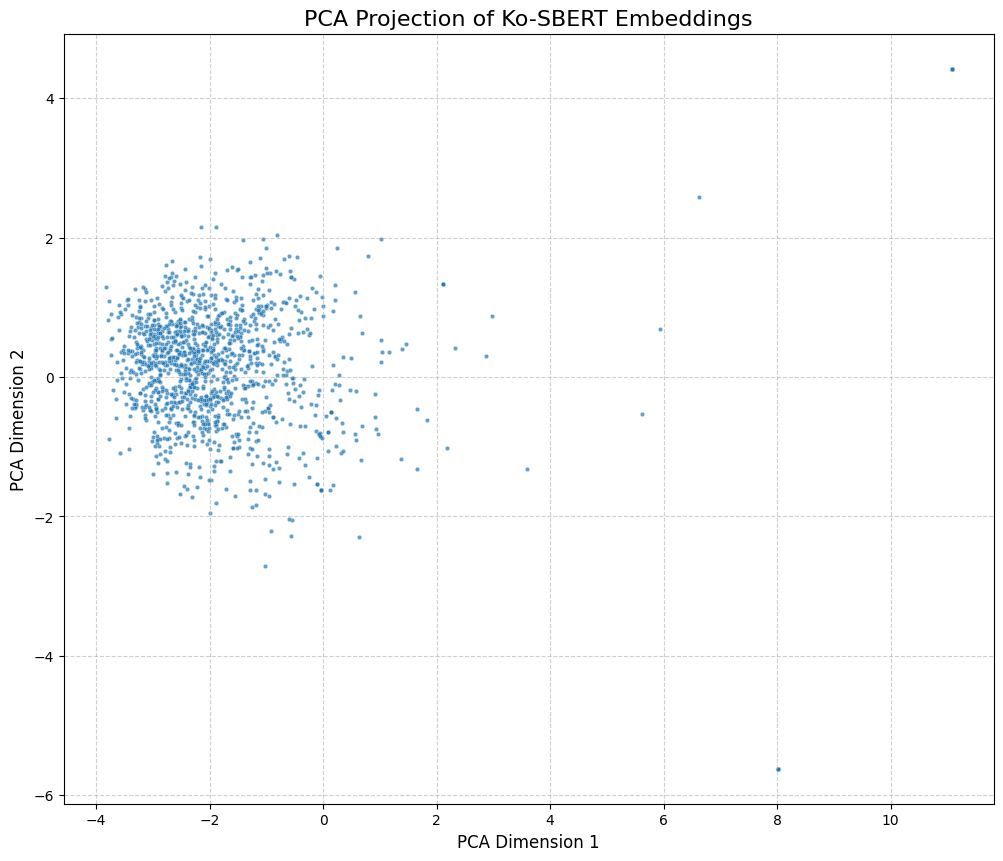

PCA plot saved to /content/output_files/pca_projection.png


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import os

# PCA 모델 설정
# n_components는 시각화를 위해 2로 설정합니다.
pca = PCA(n_components=2, random_state=42)

# Ko-SBERT 벡터에 PCA 적용
# result_df['vector']는 numpy array 형태로 변환되어야 합니다.
pca_embedding = pca.fit_transform(list(df['vector']))

# 차원 축소된 데이터를 DataFrame에 추가
df['pca_x'] = pca_embedding[:, 0]
df['pca_y'] = pca_embedding[:, 1]

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='pca_x',
    y='pca_y',
    data=df,
    s=10, # 점 크기
    alpha=0.7 # 투명도
)
plt.title('PCA Projection of Ko-SBERT Embeddings', fontsize=16)
plt.xlabel('PCA Dimension 1', fontsize=12)
plt.ylabel('PCA Dimension 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

output_dir = '/content/output_files'
os.makedirs(output_dir, exist_ok=True)
pca_filename = os.path.join(output_dir, 'pca_projection.png')
plt.savefig(pca_filename)
plt.show()
print(f"PCA plot saved to {pca_filename}")
plt.close() # Close the plot to free memory

## t -SNE

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


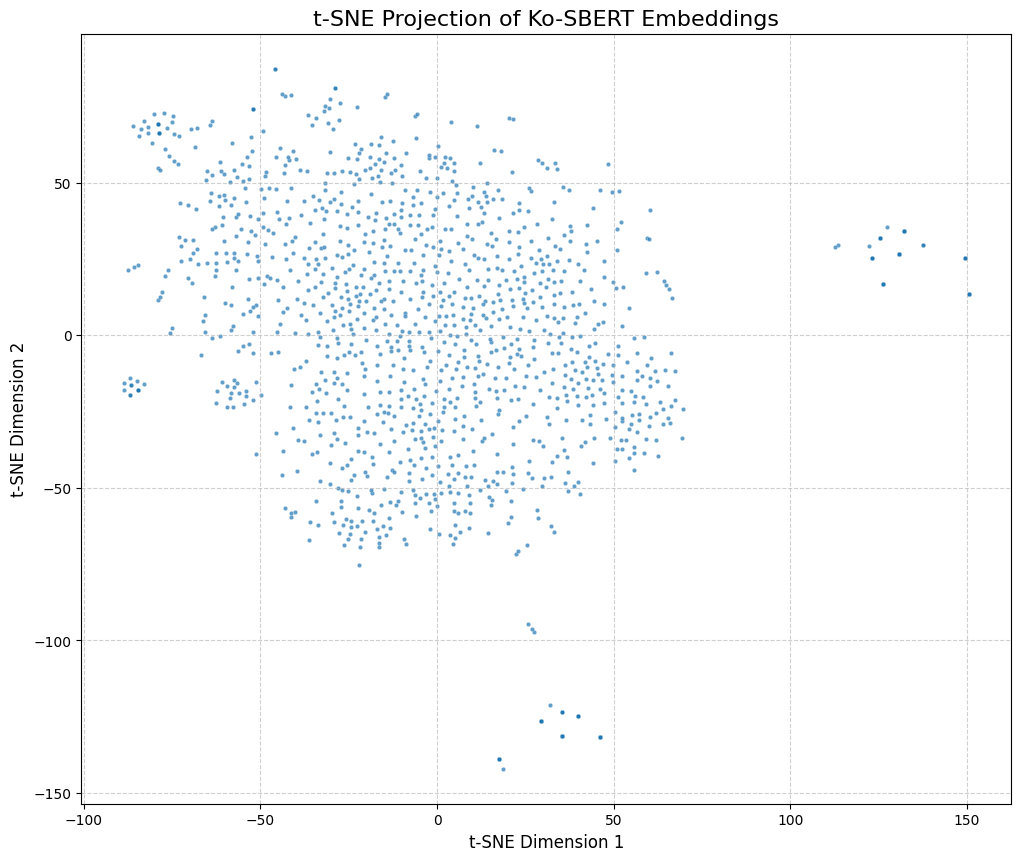

t-SNE plot saved to /content/output_files/tsne_projection.png


In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # numpy import 추가
import os

# t-SNE 모델 설정
# n_components는 시각화를 위해 2로 설정합니다.
# perplexity, learning_rate, n_iter 등의 파라미터는 데이터에 따라 조정이 필요할 수 있습니다.
# random_state를 설정하여 결과의 재현성을 확보합니다.
tsne_model = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200, n_iter=1000)

# Ko-SBERT 벡터에 t-SNE 적용
# result_df['vector']는 numpy array 형태로 변환되어야 합니다.
# list(result_df['vector'])를 numpy 배열로 변환합니다.
tsne_embedding = tsne_model.fit_transform(np.array(list(df['vector'])))

# 차원 축소된 데이터를 DataFrame에 추가
df['tsne_x'] = tsne_embedding[:, 0]
df['tsne_y'] = tsne_embedding[:, 1]

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='tsne_x',
    y='tsne_y',
    data=df,
    s=10, # 점 크기
    alpha=0.7 # 투명도
)
plt.title('t-SNE Projection of Ko-SBERT Embeddings', fontsize=16)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

output_dir = '/content/output_files'
os.makedirs(output_dir, exist_ok=True)
tsne_filename = os.path.join(output_dir, 'tsne_projection.png')
plt.savefig(tsne_filename)
plt.show()
print(f"t-SNE plot saved to {tsne_filename}")
plt.close() # Close the plot to free memory

## 파일 공유 드라이브에 저장

In [ ]:
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload
import zipfile

# 1. 데이터프레임 저장 (CSV)
df_filename = os.path.join(output_dir, 'processed_data.csv')
df.to_csv(df_filename, index=False)
print(f"DataFrame saved to {df_filename}")

# 2. 모든 결과 파일을 하나의 ZIP 파일로 압축
zip_filename = os.path.join(output_dir, 'Ko-SBERT.zip')
with zipfile.ZipFile(zip_filename, 'w') as zf:
    if os.path.exists(df_filename):
        zf.write(df_filename, os.path.basename(df_filename))
    # Check if individual plot files exist before adding to zip
    if os.path.exists(os.path.join(output_dir, 'dendrogram.png')):
        zf.write(os.path.join(output_dir, 'dendrogram.png'), os.path.basename(os.path.join(output_dir, 'dendrogram.png')))
    if os.path.exists(os.path.join(output_dir, 'umap_projection.png')):
        zf.write(os.path.join(output_dir, 'umap_projection.png'), os.path.basename(os.path.join(output_dir, 'umap_projection.png')))
    if os.path.exists(os.path.join(output_dir, 'pca_projection.png')):
        zf.write(os.path.join(output_dir, 'pca_projection.png'), os.path.basename(os.path.join(output_dir, 'pca_projection.png')))
    if os.path.exists(os.path.join(output_dir, 'tsne_projection.png')):
        zf.write(os.path.join(output_dir, 'tsne_projection.png'), os.path.basename(os.path.join(output_dir, 'tsne_projection.png')))

print(f"All results compressed into {zip_filename}")

# 3. Google Drive API를 사용하여 ZIP 파일 업로드
# Colab의 내장 인증 방식을 사용합니다. (인증은 상단 셀에서 미리 처리됨)
drive_service = build('drive', 'v3')

if os.path.exists(zip_filename):
    file_metadata = {
        'name': os.path.basename(zip_filename),
        'parents': [drive_folder_id]
    }
    media = MediaFileUpload(zip_filename, resumable=True)
    uploaded_file = drive_service.files().create(
        body=file_metadata,
        media_body=media,
        fields='id'
    ).execute()
    print(f"Uploaded '{os.path.basename(zip_filename)}' to Google Drive folder ID: {drive_folder_id}. File ID: {uploaded_file.get('id')}")
else:
    print(f"Warning: ZIP file not found for upload - {zip_filename}")

print("All specified files have been processed and uploaded to Google Drive as a ZIP archive.")

DataFrame saved to /content/output_files/processed_data.csv
All results compressed into /content/output_files/Ko-SBERT.zip
Uploaded 'Ko-SBERT.zip' to Google Drive folder ID: 1teiRbwW4ciSrKLd4bvs7kc81Y5q3lkwV. File ID: 1EuvUrQEhJH4JJGy0TCeO6ZSTukmDNA6C
All specified files have been processed and uploaded to Google Drive as a ZIP archive.
